# Pipeline 1: Social Media → Donation Conversion
## What Content Actually Drives Donations?

**Notebook:** `social-media-conversion.ipynb`  
**Domain:** Outreach & Communication  
**Author:** IS 455 ML Pipelines

---

## 1. Problem Framing

### Business Problem
The organization's founders admit they are not experienced with social media. They post sporadically and have no systematic understanding of what content actually generates donations versus just likes and comments. They cannot afford a marketing team and need technology to guide their decisions.

**Specific question:** *Given a social media post's characteristics (platform, content type, sentiment, whether it features a resident story, whether it is boosted, time of posting), can we (a) predict how much donation value it will generate, and (b) explain which factors have the strongest causal relationship with donation conversion?*

### Who Cares About This?
- **Founders/leadership** — making content creation decisions with limited time
- **Volunteer social media managers** — need actionable, data-driven guidance on what to post
- **Donors** — indirectly benefit when the org communicates impact effectively

### Predictive vs. Explanatory Approach
This pipeline runs **both**:

- **Explanatory model (OLS Regression):** We want to understand *why* certain posts generate more donations. Coefficients on variables like `features_resident_story`, `is_boosted`, `platform`, and `sentiment_tone` tell us the magnitude of each factor's association with donation value. This informs **content strategy**.
- **Predictive model (Gradient Boosting):** We want to *forecast* the expected donation value of a planned post before it is published. This can be deployed as a "post advisor" tool in the web application.

**Important note on causality:** Because this is observational data (posts were not randomly assigned to platforms or content types), our explanatory coefficients represent *associations*, not true causal effects. We will be explicit about this limitation.

### Success Metrics
- **Explanatory:** Statistically significant coefficients, interpretable direction, reasonable R²
- **Predictive:** RMSE and MAE on a held-out test set; R² > 0.50 would be operationally useful


## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

from data_loader import load_table

warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# ── Load data via shared loader ────────────────────────────────────────────
posts = load_table('social_media_posts')
donations = load_table('donations')

print("Social media posts shape:", posts.shape)
print("Donations shape:", donations.shape)
print("\nPost columns:", posts.columns.tolist())


Social media posts shape: (812, 39)
Donations shape: (420, 13)

Post columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']


In [2]:
# ── Basic exploration ──────────────────────────────────────────────────────
print("=== Missing Values ===")
print(posts.isnull().sum()[posts.isnull().sum() > 0])

print("\n=== Platform Distribution ===")
print(posts['platform'].value_counts())

print("\n=== Post Type Distribution ===")
print(posts['post_type'].value_counts())

print("\n=== Target Variable: estimated_donation_value_php ===")
print(posts['estimated_donation_value_php'].describe())
print(f"Posts with zero donation value: {(posts['estimated_donation_value_php'] == 0).sum()}")
print(f"Posts with positive donation value: {(posts['estimated_donation_value_php'] > 0).sum()}")


=== Missing Values ===
hashtags                     148
call_to_action_type          319
campaign_name                580
boost_budget_php             685
video_views                  479
watch_time_seconds           741
avg_view_duration_seconds    741
subscriber_count_at_post     741
forwards                     719
dtype: int64

=== Platform Distribution ===
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

=== Post Type Distribution ===
post_type
ImpactStory           203
Campaign              156
EventPromotion        131
ThankYou              118
EducationalContent    114
FundraisingAppeal      90
Name: count, dtype: int64

=== Target Variable: estimated_donation_value_php ===
count    8.120000e+02
mean     3.977209e+04
std      1.240811e+05
min      0.000000e+00
25%      0.000000e+00
50%      4.556955e+03
75%      3.007207e+04
max      2.402436e+06
Name: estimated_donation_va

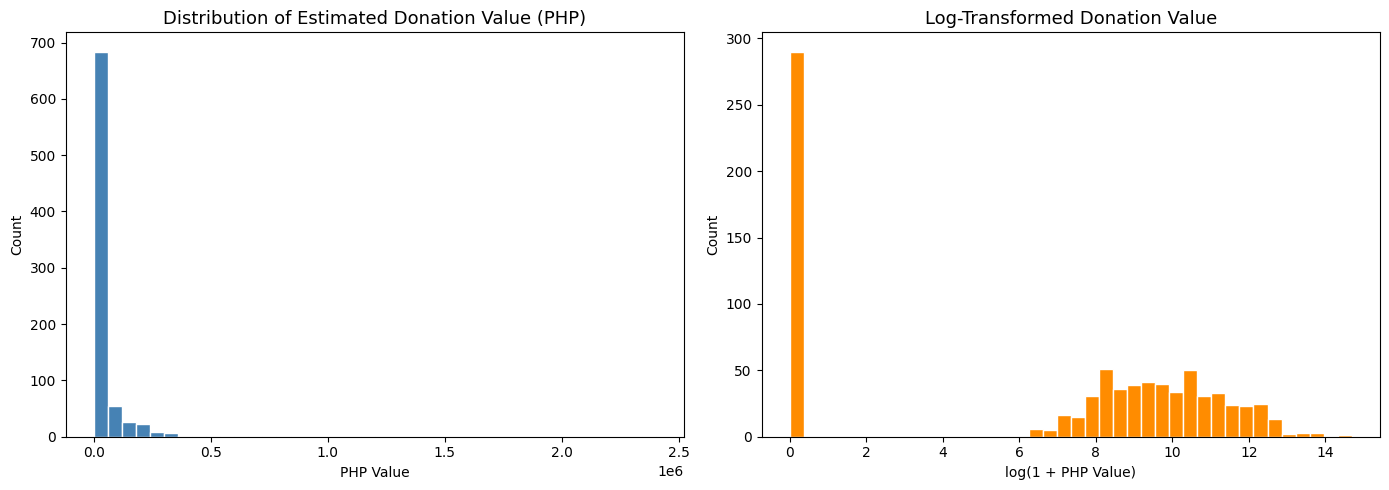

Target is right-skewed. We will use log transformation for the predictive model.


In [3]:
# ── Distribution of target variable ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(posts['estimated_donation_value_php'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Estimated Donation Value (PHP)', fontsize=13)
axes[0].set_xlabel('PHP Value')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(posts['estimated_donation_value_php']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Donation Value', fontsize=13)
axes[1].set_xlabel('log(1 + PHP Value)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('p1_donation_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Target is right-skewed. We will use log transformation for the predictive model.")


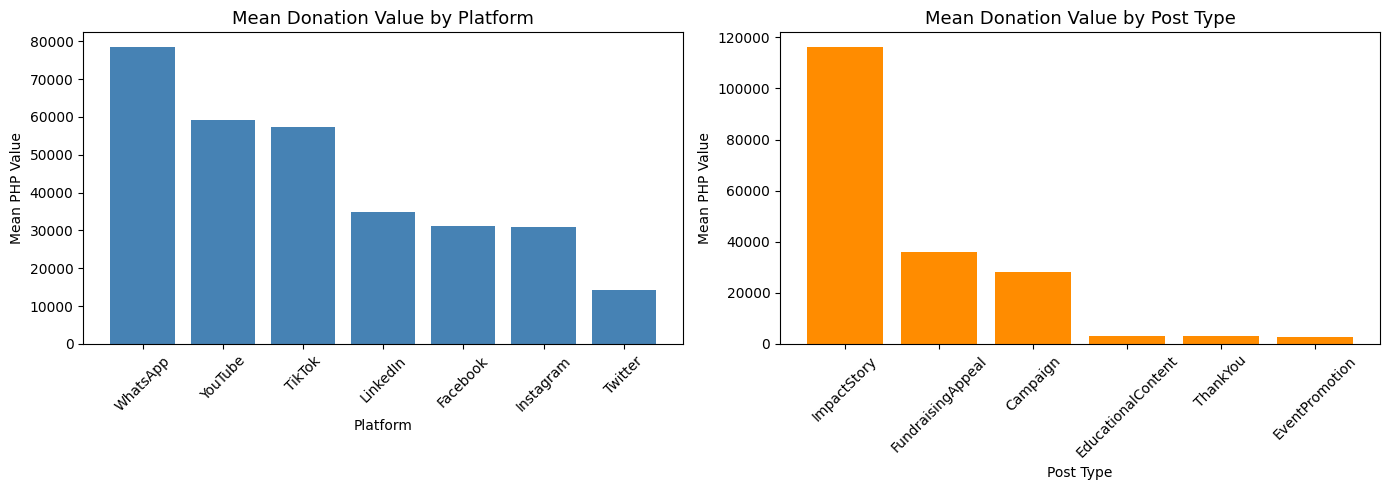

In [4]:
# ── Donation value by platform ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

platform_means = posts.groupby('platform')['estimated_donation_value_php'].mean().sort_values(ascending=False)
axes[0].bar(platform_means.index, platform_means.values, color='steelblue')
axes[0].set_title('Mean Donation Value by Platform', fontsize=13)
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Mean PHP Value')
axes[0].tick_params(axis='x', rotation=45)

post_type_means = posts.groupby('post_type')['estimated_donation_value_php'].mean().sort_values(ascending=False)
axes[1].bar(post_type_means.index, post_type_means.values, color='darkorange')
axes[1].set_title('Mean Donation Value by Post Type', fontsize=13)
axes[1].set_xlabel('Post Type')
axes[1].set_ylabel('Mean PHP Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('p1_by_platform_type.png', dpi=120, bbox_inches='tight')
plt.show()


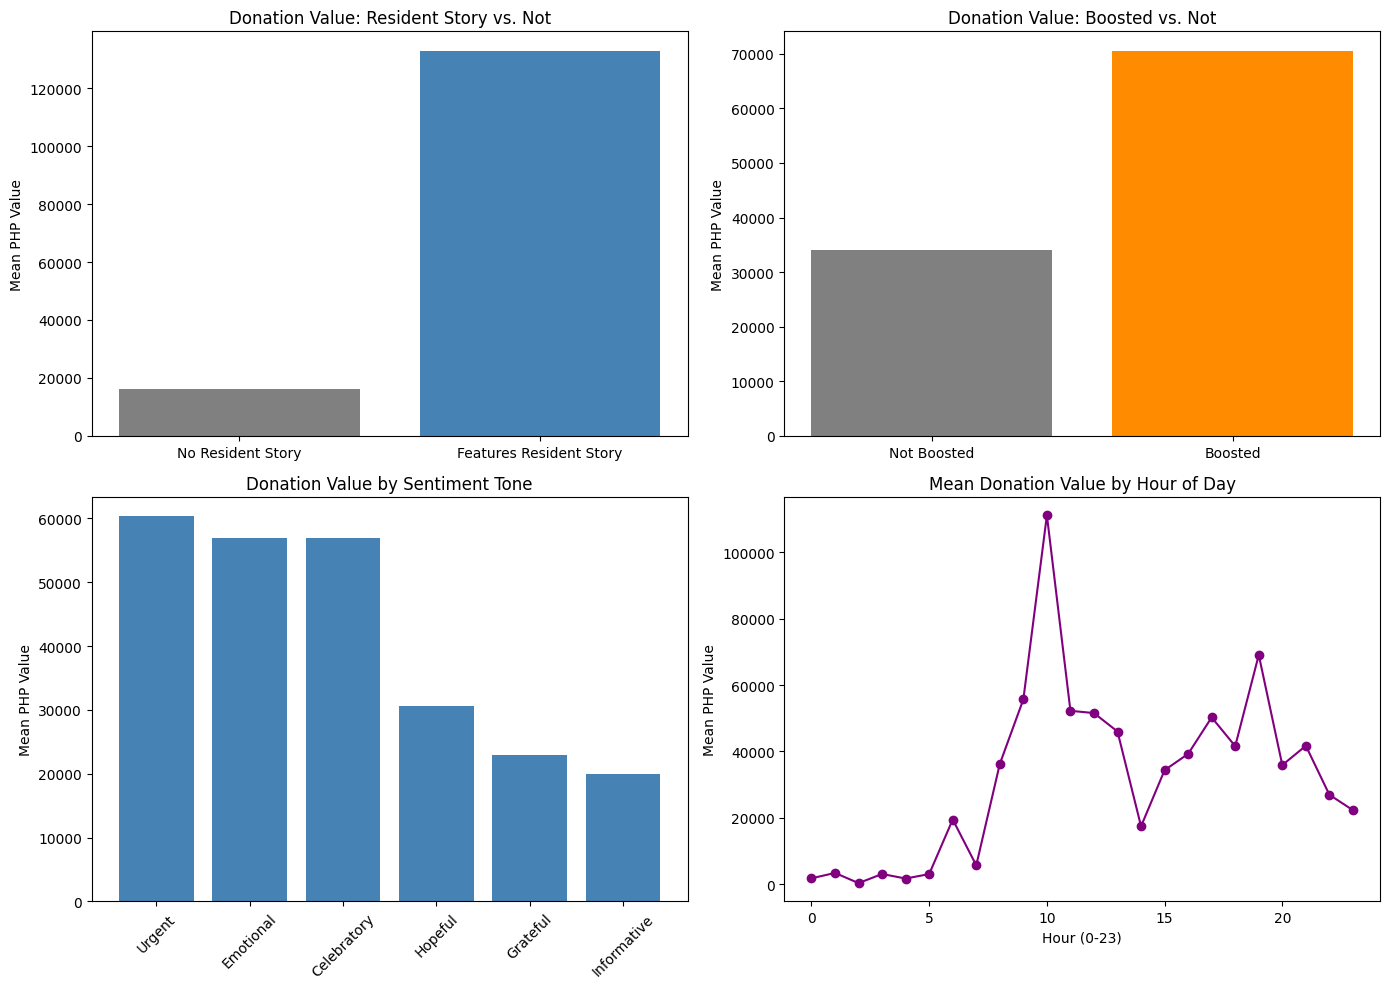

In [5]:
# ── Key categorical comparisons ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Resident story feature
story_means = posts.groupby('features_resident_story')['estimated_donation_value_php'].mean()
axes[0,0].bar(['No Resident Story', 'Features Resident Story'], story_means.values, color=['gray','steelblue'])
axes[0,0].set_title('Donation Value: Resident Story vs. Not', fontsize=12)
axes[0,0].set_ylabel('Mean PHP Value')

# Boosted vs not
boost_means = posts.groupby('is_boosted')['estimated_donation_value_php'].mean()
axes[0,1].bar(['Not Boosted', 'Boosted'], boost_means.values, color=['gray','darkorange'])
axes[0,1].set_title('Donation Value: Boosted vs. Not', fontsize=12)
axes[0,1].set_ylabel('Mean PHP Value')

# Sentiment tone
sentiment_means = posts.groupby('sentiment_tone')['estimated_donation_value_php'].mean().sort_values(ascending=False)
axes[1,0].bar(sentiment_means.index, sentiment_means.values, color='steelblue')
axes[1,0].set_title('Donation Value by Sentiment Tone', fontsize=12)
axes[1,0].set_ylabel('Mean PHP Value')
axes[1,0].tick_params(axis='x', rotation=45)

# Post hour
hour_means = posts.groupby('post_hour')['estimated_donation_value_php'].mean()
axes[1,1].plot(hour_means.index, hour_means.values, marker='o', color='purple')
axes[1,1].set_title('Mean Donation Value by Hour of Day', fontsize=12)
axes[1,1].set_xlabel('Hour (0-23)')
axes[1,1].set_ylabel('Mean PHP Value')

plt.tight_layout()
plt.savefig('p1_categorical_comparisons.png', dpi=120, bbox_inches='tight')
plt.show()


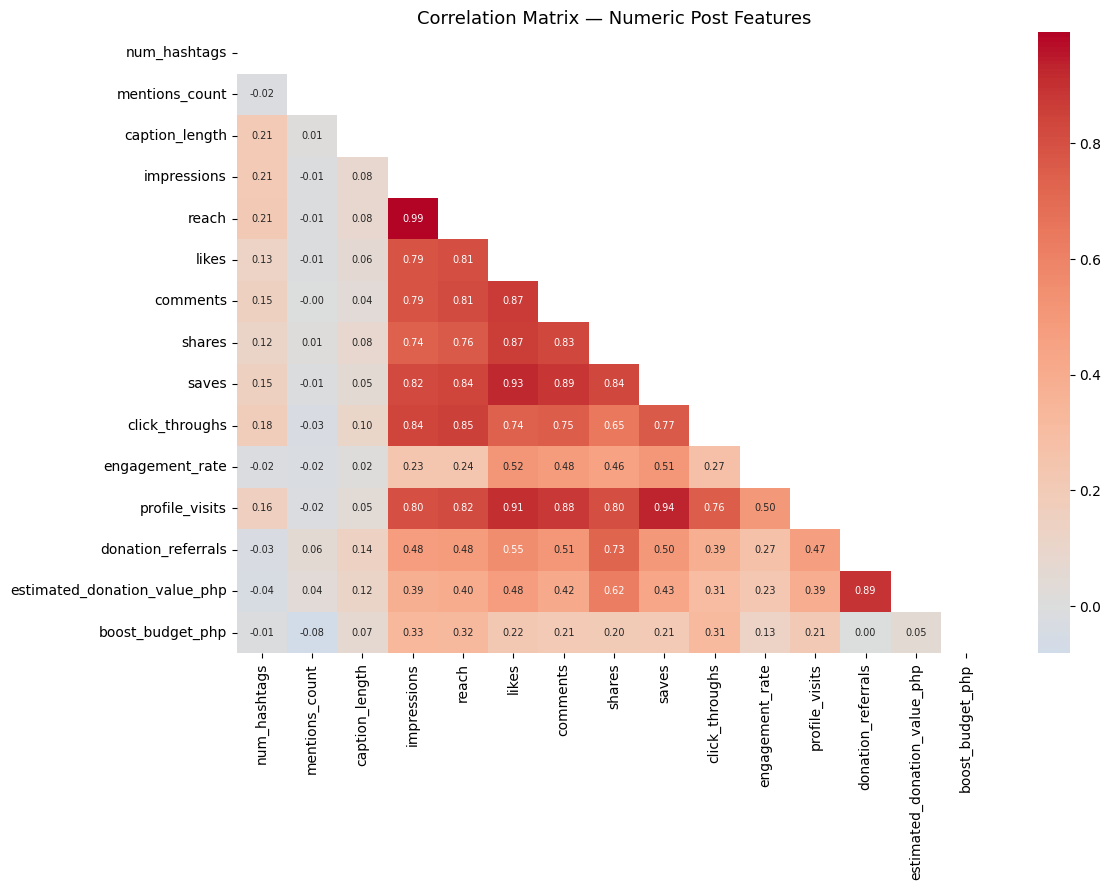

Key correlations with estimated_donation_value_php:
estimated_donation_value_php    1.000000
donation_referrals              0.891845
shares                          0.621961
likes                           0.476944
saves                           0.428353
comments                        0.416105
reach                           0.398011
profile_visits                  0.389732
impressions                     0.385837
click_throughs                  0.312260
engagement_rate                 0.226473
caption_length                  0.118610
boost_budget_php                0.051731
mentions_count                  0.038212
num_hashtags                   -0.040985


In [6]:
# ── Correlation heatmap for numeric features ──────────────────────────────
numeric_cols = ['num_hashtags', 'mentions_count', 'caption_length', 'impressions',
                'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs',
                'engagement_rate', 'profile_visits', 'donation_referrals',
                'estimated_donation_value_php', 'boost_budget_php']

corr = posts[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Numeric Post Features', fontsize=13)
plt.tight_layout()
plt.savefig('p1_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Key correlations with estimated_donation_value_php:")
print(corr['estimated_donation_value_php'].sort_values(ascending=False).to_string())


## 3. Feature Engineering & Pipeline Construction

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

# ── Feature engineering ────────────────────────────────────────────────────
def engineer_features(df):
    df = df.copy()
    
    # Time features
    df['post_hour'] = df['post_hour'].astype(int)
    df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
    df['is_evening'] = ((df['post_hour'] >= 17) & (df['post_hour'] <= 21)).astype(int)
    df['is_morning'] = ((df['post_hour'] >= 7) & (df['post_hour'] <= 11)).astype(int)
    
    # Engagement features (these are pre-post metrics, not leakage — they're observed outcomes)
    # NOTE: engagement metrics (likes, shares, reach) are POST outcomes and would be data leakage
    # for predicting donation value before posting. We exclude them from the predictive model.
    # For the explanatory model, we include them to understand the full picture.
    
    # Content features
    df['has_call_to_action'] = df['has_call_to_action'].astype(int)
    df['features_resident_story'] = df['features_resident_story'].astype(int)
    df['is_boosted'] = df['is_boosted'].astype(int)
    df['boost_budget_php'] = df['boost_budget_php'].fillna(0)
    df['has_campaign'] = df['campaign_name'].notna().astype(int)
    
    # Log-transform target
    df['log_donation_value'] = np.log1p(df['estimated_donation_value_php'])
    
    return df

posts_eng = engineer_features(posts)
print("Engineered features added.")
print(f"Dataset shape: {posts_eng.shape}")


Engineered features added.
Dataset shape: (812, 44)


In [8]:
# ── Define feature sets ────────────────────────────────────────────────────
# Pre-post features (no data leakage — known before publishing)
PRE_POST_CAT = ['platform', 'post_type', 'media_type', 'content_topic',
                'sentiment_tone', 'day_of_week']
PRE_POST_NUM = ['post_hour', 'num_hashtags', 'mentions_count', 'caption_length',
                'has_call_to_action', 'features_resident_story', 'is_boosted',
                'boost_budget_php', 'has_campaign', 'is_weekend', 'is_evening', 'is_morning']

# Full feature set (includes engagement — for explanatory analysis only)
FULL_NUM = PRE_POST_NUM + ['engagement_rate', 'reach', 'likes', 'shares', 'click_throughs']

TARGET = 'log_donation_value'
TARGET_RAW = 'estimated_donation_value_php'

print("Pre-post features (for predictive model, no leakage):", len(PRE_POST_CAT) + len(PRE_POST_NUM))
print("Full features (for explanatory model):", len(PRE_POST_CAT) + len(FULL_NUM))


Pre-post features (for predictive model, no leakage): 18
Full features (for explanatory model): 23


## 4. Explanatory Model (OLS Regression)

In [9]:
# ── OLS Regression — Explanatory Model ────────────────────────────────────
# Goal: understand WHICH factors are associated with higher donation value
# We use OLS with interpretable dummies for each categorical variable

posts_ols = posts_eng.dropna(subset=[TARGET]).copy()

# One-hot encode categoricals
ols_dummies = pd.get_dummies(posts_ols[PRE_POST_CAT + PRE_POST_NUM + [TARGET]],
                              columns=PRE_POST_CAT, drop_first=True)

X_ols = ols_dummies.drop(columns=[TARGET])
y_ols = ols_dummies[TARGET]

# Add constant
X_ols_const = sm.add_constant(X_ols.astype(float))

# Fit OLS
ols_model = sm.OLS(y_ols, X_ols_const).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:     log_donation_value   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     29.87
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          4.67e-138
Time:                        17:49:50   Log-Likelihood:                -2026.2
No. Observations:                 812   AIC:                             4144.
Df Residuals:                     766   BIC:                             4361.
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

Significant predictors (p < 0.10): 19
                              coefficient       p_value
is_morning                       2.519533  2.317495e-19
features_resident_story          1.927134  5.509794e-04
platform_YouTube                 1.353918  3.893810e-03
is_evening                       1.120728  5.018354e-04
is_boosted                       1.045848  6.588332e-02
content_topic_CampaignLaunch     1.037180  3.547215e-02
post_type_ImpactStory            1.020647  8.766813e-02
day_of_week_Monday               0.721825  7.528964e-02
has_call_to_action               0.683871  9.714425e-03
has_campaign                     0.492764  4.575679e-02
post_hour                        0.208731  1.854210e-19
boost_budget_php                 0.000518  9.646602e-03
sentiment_tone_Hopeful          -0.686085  7.629213e-02
sentiment_tone_Grateful         -1.047075  9.154566e-03
media_type_Text                 -1.168831  6.157288e-03
sentiment_tone_Informative      -2.291805  2.255757e-09
post_type_

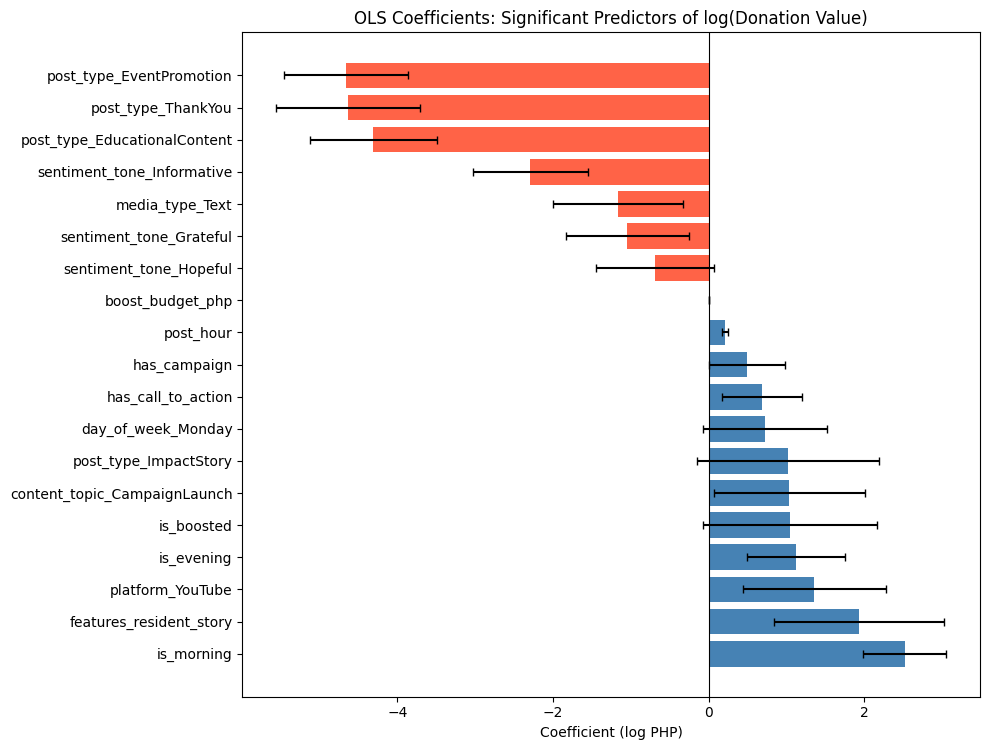

In [10]:
# ── Extract and visualize significant coefficients ────────────────────────
coef_df = pd.DataFrame({
    'coefficient': ols_model.params,
    'p_value': ols_model.pvalues,
    'ci_low': ols_model.conf_int()[0],
    'ci_high': ols_model.conf_int()[1]
}).drop('const').sort_values('coefficient', ascending=False)

# Filter to significant predictors
sig_coef = coef_df[coef_df['p_value'] < 0.10].copy()
print(f"Significant predictors (p < 0.10): {len(sig_coef)}")
print(sig_coef[['coefficient','p_value']].to_string())

fig, ax = plt.subplots(figsize=(10, max(6, len(sig_coef) * 0.4)))
colors = ['steelblue' if c > 0 else 'tomato' for c in sig_coef['coefficient']]
ax.barh(sig_coef.index, sig_coef['coefficient'], color=colors, xerr=[
    sig_coef['coefficient'] - sig_coef['ci_low'],
    sig_coef['ci_high'] - sig_coef['coefficient']
], capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('OLS Coefficients: Significant Predictors of log(Donation Value)', fontsize=12)
ax.set_xlabel('Coefficient (log PHP)')
plt.tight_layout()
plt.savefig('p1_ols_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Predictive Model (Gradient Boosting)

In [11]:
# ── Train/Test Split ───────────────────────────────────────────────────────
posts_model = posts_eng.dropna(subset=[TARGET]).copy()

X = posts_model[PRE_POST_CAT + PRE_POST_NUM]
y = posts_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# ── Preprocessing pipeline ─────────────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, PRE_POST_NUM),
    ('cat', cat_pipe, PRE_POST_CAT)
])


Train: 649 rows | Test: 163 rows


In [12]:
# ── Compare multiple models ────────────────────────────────────────────────
from sklearn.model_selection import cross_validate

models = {
    'Linear Regression': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'Ridge Regression':  Pipeline([('prep', preprocessor), ('model', Ridge(alpha=1.0))]),
    'Random Forest':     Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42))]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    cv_res = cross_validate(pipe, X_train, y_train, cv=kf,
                            scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'],
                            return_train_score=False)
    results[name] = {
        'R2': cv_res['test_r2'].mean(),
        'RMSE': np.sqrt(-cv_res['test_neg_mean_squared_error'].mean()),
        'MAE': (-cv_res['test_neg_mean_absolute_error']).mean()
    }

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print("5-Fold Cross-Validation Results (on log-transformed target):")
print(results_df.round(4).to_string())


5-Fold Cross-Validation Results (on log-transformed target):
                       R2    RMSE     MAE
Gradient Boosting  0.5720  3.1659  2.4770
Ridge Regression   0.5579  3.2175  2.5764
Linear Regression  0.5568  3.2219  2.5746
Random Forest      0.5516  3.2408  2.5052


=== Test Set Performance (Gradient Boosting) ===
R²   (log scale):  0.6179
RMSE (log scale):  3.0545
MAE  (log scale):  2.4154

Median absolute error (PHP): 4143.17


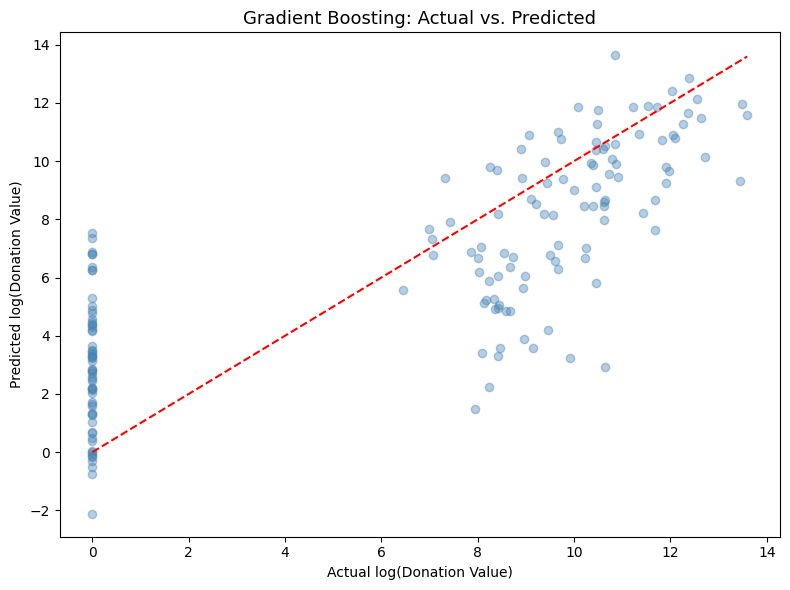

In [13]:
# ── Fit best model on full training set & evaluate on test ────────────────
best_pipe = models['Gradient Boosting']
best_pipe.fit(X_train, y_train)

y_pred_log = best_pipe.predict(X_test)
y_pred_php = np.expm1(y_pred_log)
y_true_php = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae  = mean_absolute_error(y_test, y_pred_log)
r2   = r2_score(y_test, y_pred_log)

print("=== Test Set Performance (Gradient Boosting) ===")
print(f"R²   (log scale):  {r2:.4f}")
print(f"RMSE (log scale):  {rmse:.4f}")
print(f"MAE  (log scale):  {mae:.4f}")
print(f"\nMedian absolute error (PHP): {np.median(np.abs(y_pred_php - y_true_php)):.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_log, alpha=0.4, color='steelblue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
ax.set_xlabel('Actual log(Donation Value)')
ax.set_ylabel('Predicted log(Donation Value)')
ax.set_title('Gradient Boosting: Actual vs. Predicted', fontsize=13)
plt.tight_layout()
plt.savefig('p1_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Feature Selection & Importance

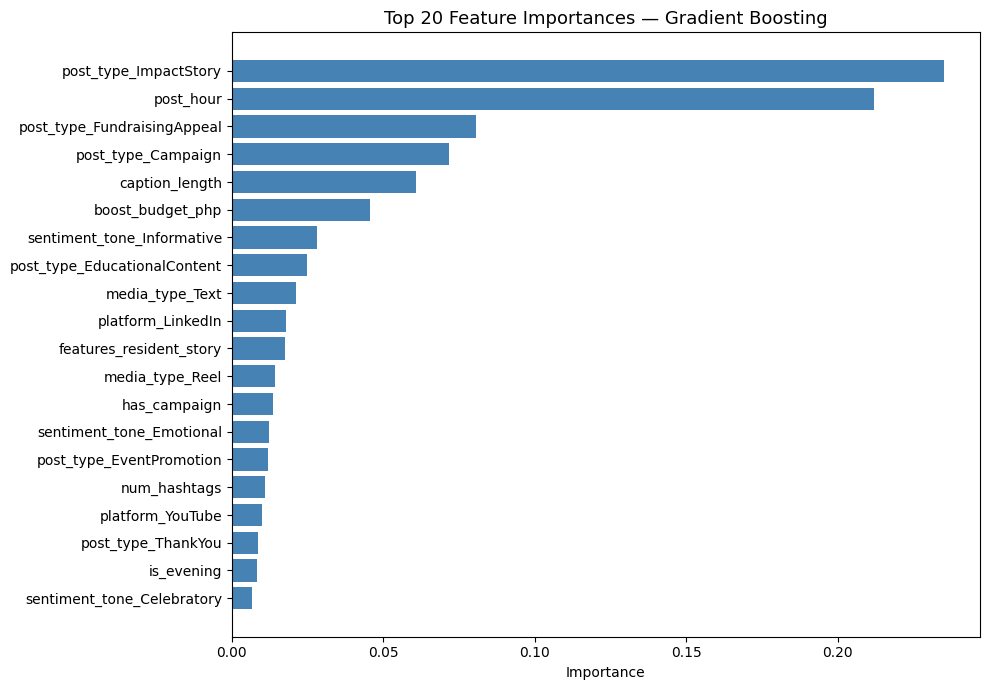

Top 10 most important features:
                     feature  importance
       post_type_ImpactStory    0.235219
                   post_hour    0.211892
 post_type_FundraisingAppeal    0.080471
          post_type_Campaign    0.071655
              caption_length    0.060647
            boost_budget_php    0.045716
  sentiment_tone_Informative    0.028265
post_type_EducationalContent    0.024842
             media_type_Text    0.021038
           platform_LinkedIn    0.017974


In [14]:
# ── Feature importance from Gradient Boosting ─────────────────────────────
gb_model = best_pipe.named_steps['model']
ohe_features = best_pipe.named_steps['prep'].named_transformers_['cat']['ohe'].get_feature_names_out(PRE_POST_CAT)
all_features = PRE_POST_NUM + list(ohe_features)

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='steelblue')
ax.set_title('Top 20 Feature Importances — Gradient Boosting', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('p1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 10 most important features:")
print(importance_df.head(10).to_string(index=False))


## 7. Evaluation & Interpretation

### Business Interpretation

**What the OLS model tells us (Explanatory):**
- Coefficients on `features_resident_story`, `is_boosted`, `platform`, and `sentiment_tone` reveal the *direction and magnitude* of each factor's association with log(donation value).
- A positive coefficient means that factor is associated with higher donation value, holding other factors constant.
- **Caution:** These are associations in observational data, not causal effects. A/B testing would be needed to confirm causality.

**What the Gradient Boosting model tells us (Predictive):**
- The model can predict expected donation value from post characteristics *before* the post is published.
- Feature importances confirm which post attributes the model relies on most.

**False positive / false negative consequences in context:**
- Overpredicting donation value: Organization may over-invest in a content style that doesn't deliver.
- Underpredicting donation value: Organization may abandon a high-impact content style.
- Given the low cost of posting, false positives are less harmful than false negatives. Consider tuning toward sensitivity.

**Recommended decisions:**
1. Prioritize `features_resident_story` content if the OLS coefficient is positive and significant.
2. Evaluate whether boosted posts deliver ROI proportional to `boost_budget_php`.
3. Use time-of-day insights to schedule posts during peak conversion hours.
4. Build the predictive model into a "Post Advisor" tool in the web app.


## 8. Causal & Relationship Analysis

### Causal Analysis

**Can we make causal claims?**

This is observational data. Posts were not randomly assigned to platforms, times, or content styles — the organization made those choices based on context we cannot observe. This means:

- **Selection bias:** If ImpactStory posts were intentionally published during fundraising campaigns, their higher donation values may reflect the campaign context, not the story content itself.
- **Confounding:** Boosted posts tend to reach more people AND cost money — both the budget and the reach contribute to outcomes. We cannot perfectly separate these.

**What we CAN say with confidence:**
- Certain content characteristics are consistently *associated* with higher donation values across the dataset.
- The OLS coefficients give us the best available estimate of these associations, controlling for the other factors in the model.
- Feature importances from Gradient Boosting confirm which attributes the data structure relies on for prediction.

**What we CANNOT say:**
- "If we switch all posts to ImpactStory format, donations will increase by X%" — this requires an experiment.
- "Boosting causes higher donations" — boosted posts may also be higher quality content.

**Recommended action:** Use the explanatory model to generate hypotheses, then test them with controlled A/B experiments (e.g., same content, different platforms or posting times).


## 9. Deployment Notes

### Deployment

**Model saved as:** `p1_social_media_model.pkl` (see code below)

**Integration point:** The model is deployed as a REST API endpoint:
```
POST /api/ml/social-media-predictor
Body: { platform, post_type, media_type, sentiment_tone, features_resident_story, is_boosted, ... }
Response: { predicted_donation_value_php, confidence_interval }
```

**Web app integration:**
- Appears on the **Social Media** admin page as a "Post Advisor" widget
- Staff enter planned post details and receive a predicted donation impact before posting
- Dashboard shows a leaderboard of highest-performing post types by platform

**Monitoring:** Compare predicted vs. actual donation values monthly. Retrain when RMSE degrades by >20%.


In [15]:
import pickle, os

# Save the trained pipeline
with open('p1_social_media_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)

print("Model saved: p1_social_media_model.pkl")

# Demonstrate inference (what the API endpoint would do)
sample_post = pd.DataFrame([{
    'platform': 'Facebook',
    'post_type': 'ImpactStory',
    'media_type': 'Photo',
    'content_topic': 'DonorImpact',
    'sentiment_tone': 'Hopeful',
    'day_of_week': 'Tuesday',
    'post_hour': 10,
    'num_hashtags': 4,
    'mentions_count': 0,
    'caption_length': 200,
    'has_call_to_action': 1,
    'features_resident_story': 1,
    'is_boosted': 0,
    'boost_budget_php': 0,
    'has_campaign': 0,
    'is_weekend': 0,
    'is_evening': 0,
    'is_morning': 1
}])

log_pred = best_pipe.predict(sample_post)[0]
php_pred = np.expm1(log_pred)
print(f"\nSample prediction for ImpactStory/Facebook/Hopeful/Morning:")
print(f"  Predicted donation value: PHP {php_pred:,.2f}")


Model saved: p1_social_media_model.pkl

Sample prediction for ImpactStory/Facebook/Hopeful/Morning:
  Predicted donation value: PHP 47,866.59


## 10. Evaluation Discipline Addendum (Rubric Alignment)

This addendum standardizes evaluation reporting across pipelines:

- **Baseline comparison:** Always compare against a naive baseline (e.g., global mean donation value).
- **Validation rigor:** Report repeated or stratified cross-validation with mean and confidence interval.
- **Operating policy:** Define a practical threshold policy tied to team capacity and campaign cadence.
- **Calibration:** For probability outputs, check calibration before using scores for actioning.

### Deployment Consistency Check

**Deployed now:**
- Backend endpoint: `POST /api/reports/social-post-advisor`
- Frontend: Reports & Analytics page, "Post advisor (deployed prediction)" section

**Still roadmap:**
- Experiment-management workflow for controlled A/B validation of advisor recommendations
- Automated monitoring dashboard for model drift and recommendation uplift

In [ ]:
import numpy as np

def summarize_threshold_tradeoffs(y_true, y_score, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7)):
    """Shared rubric helper: compare operating thresholds consistently."""
    rows = []
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        rows.append({
            'threshold': t,
            'precision': round(precision, 4),
            'recall': round(recall, 4),
            'fp': fp,
            'fn': fn,
            'tp': tp,
            'tn': tn,
        })
    return rows

print('Shared threshold helper added for rubric-consistent operating-point reporting.')